In [1]:
from google.colab import files
uploaded = files.upload()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score,classification_report

In [8]:
df=pd.read_csv("HR-Employee-Attrition.csv")
print(df.shape)
print(df.info())
print(df.head())

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

In [9]:
print(df["Attrition"].value_counts())
print(df["Attrition"].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [11]:
print("EmployeeCount:", df["EmployeeCount"].unique())
print("Over18:", df["Over18"].unique())
print("StandardHours:", df["StandardHours"].unique())

df = df.drop(["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"], axis=1)
print(df.shape)

EmployeeCount: [1]
Over18: ['Y']
StandardHours: [80]
(1470, 31)


In [12]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(categorical_cols)

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Attrition:
['Yes' 'No']

BusinessTravel:
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department:
['Sales' 'Research & Development' 'Human Resources']

EducationField:
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender:
['Female' 'Male']

JobRole:
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus:
['Single' 'Married' 'Divorced']

OverTime:
['Yes' 'No']


In [13]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
df["OverTime"] = df["OverTime"].map({"Yes": 1, "No": 0})

travel_map = {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}
df["BusinessTravel"] = df["BusinessTravel"].map(travel_map)

nominal_cols = ["Department", "EducationField", "JobRole", "MaritalStatus"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(df.shape)
print(df.select_dtypes(include=["object"]).columns.tolist())

(1470, 44)
[]


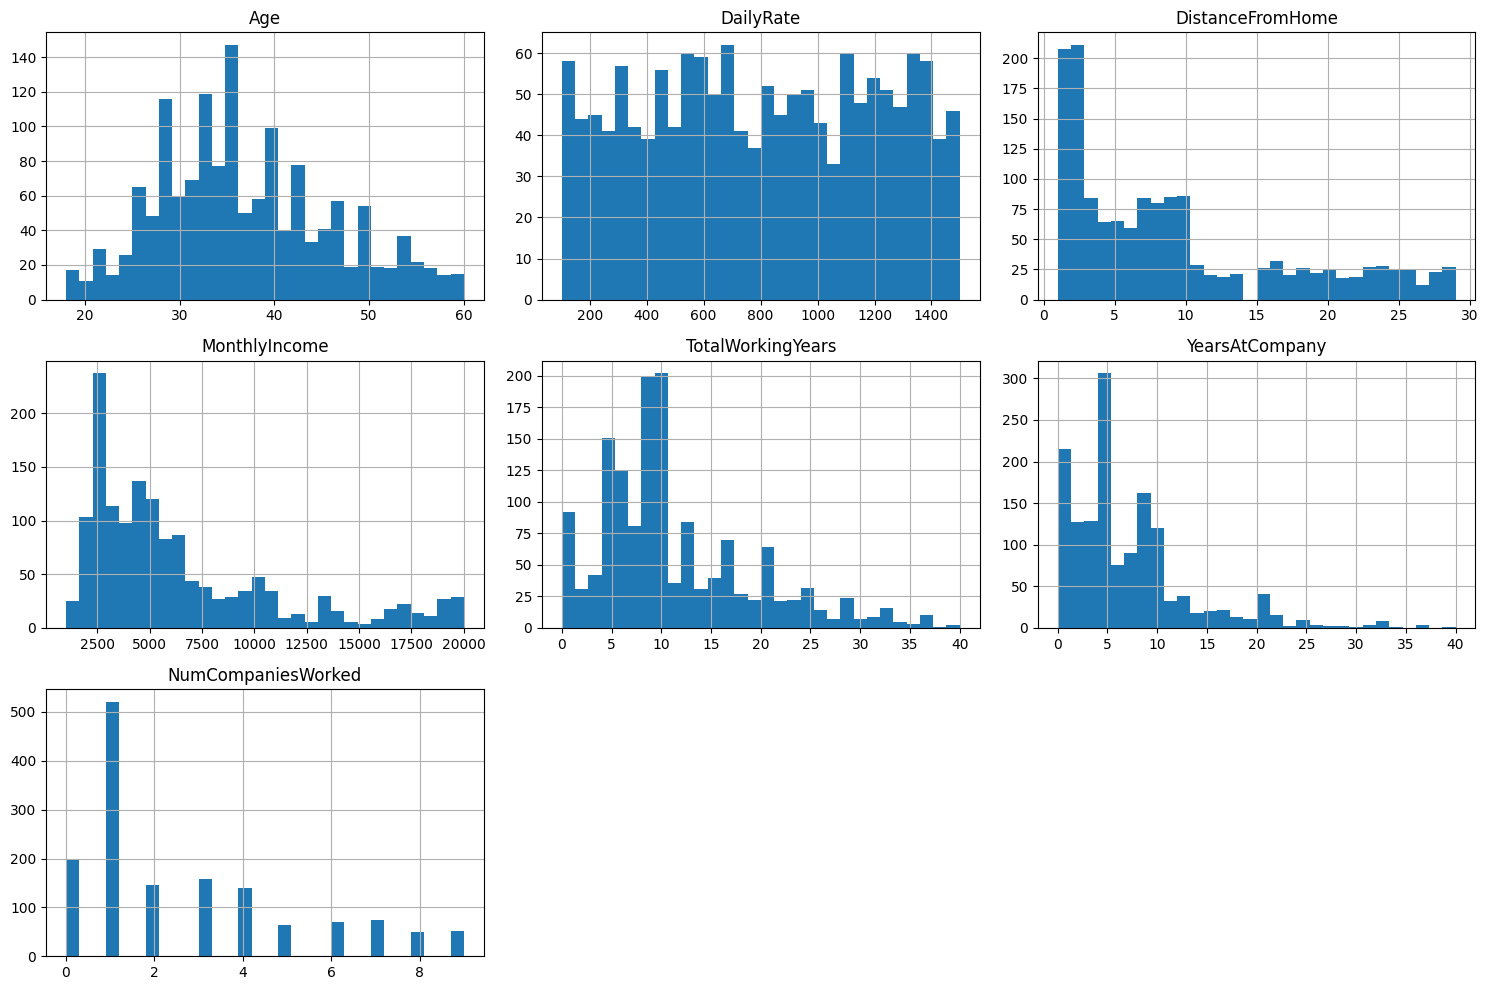

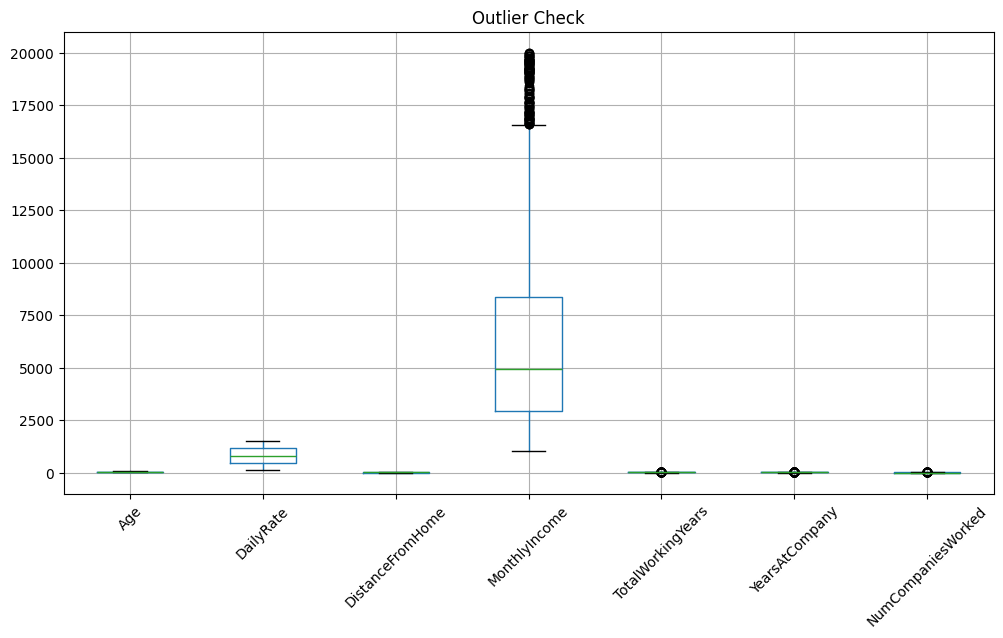

In [14]:
numeric_check_cols = ["Age", "DailyRate", "DistanceFromHome", "MonthlyIncome",
                        "TotalWorkingYears", "YearsAtCompany", "NumCompaniesWorked"]

df[numeric_check_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
df[numeric_check_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Outlier Check")
plt.show()

In [15]:
print("OverTime vs Attrition:")
print(pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100)

print("\nBusinessTravel vs Attrition:")
print(pd.crosstab(df["BusinessTravel"], df["Attrition"], normalize="index") * 100)

OverTime vs Attrition:
Attrition          0          1
OverTime                       
0          89.563567  10.436433
1          69.471154  30.528846

BusinessTravel vs Attrition:
Attrition               0          1
BusinessTravel                      
0               92.000000   8.000000
1               85.043145  14.956855
2               75.090253  24.909747


In [17]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, max_depth=6,
                                  class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       247
           1       0.49      0.36      0.41        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.66       294
weighted avg       0.82      0.84      0.83       294

AUC Score: 0.7661297269359979


In [18]:
for threshold in [0.2, 0.3, 0.4, 0.5]:
    y_pred_custom = (y_pred_proba >= threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred_custom))


--- Threshold: 0.2 ---
              precision    recall  f1-score   support

           0       0.94      0.18      0.31       247
           1       0.18      0.94      0.30        47

    accuracy                           0.30       294
   macro avg       0.56      0.56      0.30       294
weighted avg       0.82      0.30      0.30       294


--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.95      0.55      0.70       247
           1       0.26      0.85      0.40        47

    accuracy                           0.60       294
   macro avg       0.61      0.70      0.55       294
weighted avg       0.84      0.60      0.65       294


--- Threshold: 0.4 ---
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       247
           1       0.39      0.62      0.48        47

    accuracy                           0.79       294
   macro avg       0.66      0.72      0.67       294
we

In [20]:
def predict_attrition(age, daily_rate, distance_from_home, education,
                        environment_satisfaction, gender, hourly_rate,
                        job_involvement, job_level, job_satisfaction,
                        monthly_income, monthly_rate, num_companies_worked,
                        overtime, percent_salary_hike, performance_rating,
                        relationship_satisfaction, stock_option_level,
                        total_working_years, training_times_last_year,
                        work_life_balance, years_at_company, years_in_current_role,
                        years_since_last_promotion, years_with_curr_manager,
                        business_travel, department, education_field,
                        job_role, marital_status, threshold=0.4):


    data = {
        "Age": age,
        "DailyRate": daily_rate,
        "DistanceFromHome": distance_from_home,
        "Education": education,
        "EnvironmentSatisfaction": environment_satisfaction,
        "Gender": 1 if gender == "Male" else 0,
        "HourlyRate": hourly_rate,
        "JobInvolvement": job_involvement,
        "JobLevel": job_level,
        "JobSatisfaction": job_satisfaction,
        "MonthlyIncome": monthly_income,
        "MonthlyRate": monthly_rate,
        "NumCompaniesWorked": num_companies_worked,
        "OverTime": 1 if overtime == "Yes" else 0,
        "PercentSalaryHike": percent_salary_hike,
        "PerformanceRating": performance_rating,
        "RelationshipSatisfaction": relationship_satisfaction,
        "StockOptionLevel": stock_option_level,
        "TotalWorkingYears": total_working_years,
        "TrainingTimesLastYear": training_times_last_year,
        "WorkLifeBalance": work_life_balance,
        "YearsAtCompany": years_at_company,
        "YearsInCurrentRole": years_in_current_role,
        "YearsSinceLastPromotion": years_since_last_promotion,
        "YearsWithCurrManager": years_with_curr_manager,
        "BusinessTravel": {"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}[business_travel],
    }

    one_hot_template = {col: False for col in X_train.columns if col not in data}
    data.update(one_hot_template)

    if f"Department_{department}" in data:
        data[f"Department_{department}"] = True
    if f"EducationField_{education_field}" in data:
        data[f"EducationField_{education_field}"] = True
    if f"JobRole_{job_role}" in data:
        data[f"JobRole_{job_role}"] = True
    if f"MaritalStatus_{marital_status}" in data:
        data[f"MaritalStatus_{marital_status}"] = True

    input_df = pd.DataFrame([data])
    input_df = input_df[X_train.columns]

    probability = model.predict_proba(input_df)[:, 1][0]
    prediction = "Will Leave" if probability >= threshold else "Will Stay"

    return f"Attrition Probability: {probability:.2%} | Prediction: {prediction}"

In [21]:
result = predict_attrition(
    age=35, daily_rate=800, distance_from_home=10, education=3,
    environment_satisfaction=2, gender="Male", hourly_rate=60,
    job_involvement=3, job_level=2, job_satisfaction=2,
    monthly_income=5000, monthly_rate=15000, num_companies_worked=2,
    overtime="Yes", percent_salary_hike=12, performance_rating=3,
    relationship_satisfaction=3, stock_option_level=0,
    total_working_years=10, training_times_last_year=2,
    work_life_balance=2, years_at_company=5, years_in_current_role=3,
    years_since_last_promotion=1, years_with_curr_manager=3,
    business_travel="Travel_Frequently", department="Research & Development",
    education_field="Life Sciences", job_role="Research Scientist",
    marital_status="Single"
)
print(result)

Attrition Probability: 43.28% | Prediction: Will Leave
